<a href="https://colab.research.google.com/github/PSD-20/Portfolio-Optimization/blob/main/portf_optmzn_ML_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine-Learning-Assisted Portfolio Optimization





In [1]:
# Cell 1 — Imports and reproducibility
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.optimize import minimize

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Random state:", RANDOM_STATE)

Random state: 42


In [2]:
# Cell 2 — Preserve the original notebook inputs
assets = ["A", "B", "C", "D"]

# Original manually entered expected returns (annual units as written in baseline notebook)
mu_original = np.array([0.08, 0.12, 0.15, 0.07], dtype=float)

# Original matrix exactly as entered in the baseline notebook
Sigma_original = np.array([
    [0.04,  0.01,  0.005, 0.002],
    [0.01,  0.07,  0.015, 0.003],
    [0.01,  0.07,  0.015, 0.003],
    [0.002, 0.003, 0.004, 0.03]
], dtype=float)

gamma = 1.0  # preserved from the original notebook
TRADING_PERIODS = 252

print("Assets:", assets)
print("Original mu:", mu_original)
print("Original gamma:", gamma)
print("Is original Sigma symmetric?", np.allclose(Sigma_original, Sigma_original.T))
if not np.allclose(Sigma_original, Sigma_original.T):
    print("NOTE: the original Sigma is not symmetric, so it is not used as the ML covariance matrix.")
    print("The ML section computes Sigma from the historical return series instead.")

Assets: ['A', 'B', 'C', 'D']
Original mu: [0.08 0.12 0.15 0.07]
Original gamma: 1.0
Is original Sigma symmetric? False
NOTE: the original Sigma is not symmetric, so it is not used as the ML covariance matrix.
The ML section computes Sigma from the historical return series instead.


In [3]:
# Cell 3 — Historical price input
# The baseline notebook has no historical price table.
# For a real project, set USE_DEMO_DATA = False and provide a CSV containing:
# Date, A, B, C, D   (or change `assets` above to match your real asset columns).

USE_DEMO_DATA = True
CSV_PATH = "portfolio_prices.csv"
DATE_COLUMN = "Date"

if USE_DEMO_DATA:
    print("DEMONSTRATION MODE: generating a reproducible price history from the baseline inputs.")
    print("Replace this with real historical prices before reporting real investment results.\n")

    # The original Sigma is asymmetric. For simulation only, symmetrize it and
    # clip negative eigenvalues so a valid covariance can be sampled.
    Sigma_demo = 0.5 * (Sigma_original + Sigma_original.T)
    eigval, eigvec = np.linalg.eigh(Sigma_demo)
    eigval = np.clip(eigval, 1e-6, None)
    Sigma_demo = eigvec @ np.diag(eigval) @ eigvec.T

    n_periods = 756  # ~3 trading years
    rng = np.random.default_rng(RANDOM_STATE)
    daily_returns_demo = rng.multivariate_normal(
        mean=mu_original / TRADING_PERIODS,
        cov=Sigma_demo / TRADING_PERIODS,
        size=n_periods
    )

    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=n_periods)
    prices = pd.DataFrame(
        100.0 * np.cumprod(1.0 + daily_returns_demo, axis=0),
        index=dates, columns=assets
    )
    prices.index.name = DATE_COLUMN
else:
    raw = pd.read_csv(CSV_PATH)
    if DATE_COLUMN not in raw.columns:
        raise ValueError(f"Expected date column '{DATE_COLUMN}'. Found: {list(raw.columns)}")
    missing_assets = [a for a in assets if a not in raw.columns]
    if missing_assets:
        raise ValueError(f"Missing asset columns in CSV: {missing_assets}")
    raw[DATE_COLUMN] = pd.to_datetime(raw[DATE_COLUMN])
    prices = (raw[[DATE_COLUMN] + assets]
              .sort_values(DATE_COLUMN)
              .drop_duplicates(DATE_COLUMN)
              .set_index(DATE_COLUMN)
              .astype(float))

print("Price data shape:", prices.shape)
print("Date range:", prices.index.min().date(), "to", prices.index.max().date())
display(prices.head())

DEMONSTRATION MODE: generating a reproducible price history from the baseline inputs.
Replace this with real historical prices before reporting real investment results.

Price data shape: (756, 4)
Date range: 2023-10-11 to 2026-09-02


,A,B,C,D
Date,,,,
2023-10-11,98.803619,99.859973,99.852012,99.009058
2023-10-12,98.160729,103.506152,101.808804,98.949062
2023-10-13,97.356514,103.871027,101.941302,97.906598
2023-10-16,98.724354,103.518311,101.840710,97.620356
2023-10-17,97.631024,103.244689,101.626863,96.523819


In [4]:
# Cell 4 — Preprocessing and return calculation
# Preserve a simple price -> percentage-return structure.
prices = prices.replace([np.inf, -np.inf], np.nan).dropna(how="any")
returns = prices.pct_change().replace([np.inf, -np.inf], np.nan).dropna(how="any")

print("Clean price rows:", len(prices))
print("Return rows:", len(returns))
print("Assets used:", list(returns.columns))
display(returns.head())

Clean price rows: 756
Return rows: 755
Assets used: ['A', 'B', 'C', 'D']


,A,B,C,D
Date,,,,
2023-10-12,-0.006507,0.036513,0.019597,-0.000606
2023-10-13,-0.008193,0.003525,0.001301,-0.010535
2023-10-16,0.014050,-0.003396,-0.000987,-0.002924
2023-10-17,-0.011075,-0.002643,-0.002100,-0.011233
2023-10-18,-0.004897,0.006026,0.002699,-0.013689


## Feature engineering without leakage
For each asset and each target date \(t\):

- **Target**: \(y_t = r_t\), the return at date \(t\).
- **Features** use only information available at \(t-1\) or earlier.

Thus the Random Forest learns **past information → next-period return**. No feature uses the target return itself.

In [5]:
# Cell 5 — Leakage-safe financial feature engineering
def build_asset_dataset(price_series, return_series, rolling_window=5):
    df = pd.DataFrame(index=return_series.index)

    # All predictors are shifted so they are known BEFORE the target return.
    df["previous_return"] = return_series.shift(1)
    df["lagged_return_2"] = return_series.shift(2)
    df[f"rolling_return_{rolling_window}"] = return_series.shift(1).rolling(rolling_window).mean()
    df[f"rolling_volatility_{rolling_window}"] = return_series.shift(1).rolling(rolling_window).std()
    df[f"momentum_{rolling_window}"] = price_series.shift(1) / price_series.shift(rolling_window + 1) - 1.0

    # y_t is the next return relative to the latest information used in X_t.
    df["target_return"] = return_series
    return df.dropna()

asset_datasets = {
    asset: build_asset_dataset(prices[asset], returns[asset])
    for asset in assets
}

example_asset = assets[0]
print(f"Example feature matrix for {example_asset}:")
display(asset_datasets[example_asset].head(10))
print("\nX columns:", list(asset_datasets[example_asset].drop(columns="target_return").columns))
print("y column: target_return")

Example feature matrix for A:


,previous_return,lagged_return_2,rolling_return_5,rolling_volatility_5,momentum_5,target_return
Date,,,,,,
2023-10-19,-0.004897,-0.011075,-0.003324,0.009978,-0.016707,-0.001132
2023-10-20,-0.001132,-0.004897,-0.002249,0.009838,-0.011387,0.007142
2023-10-23,0.007142,-0.001132,0.000818,0.009912,0.003898,-0.006062
2023-10-24,-0.006062,0.007142,-0.003205,0.006788,-0.016013,-0.010424
2023-10-25,-0.010424,-0.006062,-0.003075,0.006603,-0.015365,0.002459
2023-10-26,0.002459,-0.010424,-0.001603,0.006908,-0.008086,0.003822
2023-10-27,0.003822,0.002459,-0.000613,0.007335,-0.003166,-0.001291
2023-10-30,-0.001291,0.003822,-0.002299,0.005944,-0.011512,0.001965
2023-10-31,0.001965,-0.001291,-0.000694,0.005754,-0.003529,0.017635



X columns: ['previous_return', 'lagged_return_2', 'rolling_return_5', 'rolling_volatility_5', 'momentum_5']
y column: target_return


In [6]:
# Cell 6 — Chronological train/test split + one Random Forest per asset
TEST_FRACTION = 0.20
RF_PARAMS = {
    "n_estimators": 100,
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

models = {}
splits = {}
predictions = {}
metrics_rows = []
importance_rows = []

for asset in assets:
    data = asset_datasets[asset]
    X = data.drop(columns="target_return")
    y = data["target_return"]

    split_idx = int(len(data) * (1.0 - TEST_FRACTION))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    model = RandomForestRegressor(**RF_PARAMS)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    models[asset] = model
    splits[asset] = (X_train, X_test, y_train, y_test)
    predictions[asset] = pd.Series(y_pred, index=y_test.index, name="Predicted")

    metrics_rows.append({"Asset": asset, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2,
                         "Train rows": len(X_train), "Test rows": len(X_test)})
    for feature, importance in zip(X.columns, model.feature_importances_):
        importance_rows.append({"Asset": asset, "Feature": feature, "Importance": importance})

metrics_df = pd.DataFrame(metrics_rows).set_index("Asset")
feature_importance_df = pd.DataFrame(importance_rows)

print("Random Forest parameters:", RF_PARAMS)
print("Chronological split: first 80% train, last 20% test; shuffle=False by construction.\n")
display(metrics_df)

# Explicitly show shapes requested for the first asset.
X_train, X_test, y_train, y_test = splits[example_asset]
print(f"\n{example_asset} X_train shape:", X_train.shape)
print(f"{example_asset} X_test shape:", X_test.shape)
print(f"{example_asset} y_train shape:", y_train.shape)
print(f"{example_asset} y_test shape:", y_test.shape)
display(X_train.head())
display(X_test.head())

Random Forest parameters: {'n_estimators': 100, 'random_state': 42, 'n_jobs': -1}
Chronological split: first 80% train, last 20% test; shuffle=False by construction.



,MAE,MSE,RMSE,R2,Train rows,Test rows
Asset,,,,,,
A,0.011058,0.000198,0.014067,-0.275396,600,150
B,0.014122,0.000292,0.017075,-0.186273,600,150
C,0.007264,0.000079,0.008892,-0.087912,600,150
D,0.009498,0.000131,0.011436,-0.090549,600,150



A X_train shape: (600, 5)
A X_test shape: (150, 5)
A y_train shape: (600,)
A y_test shape: (150,)


,previous_return,lagged_return_2,rolling_return_5,rolling_volatility_5,momentum_5
Date,,,,,
2023-10-19,-0.004897,-0.011075,-0.003324,0.009978,-0.016707
2023-10-20,-0.001132,-0.004897,-0.002249,0.009838,-0.011387
2023-10-23,0.007142,-0.001132,0.000818,0.009912,0.003898
2023-10-24,-0.006062,0.007142,-0.003205,0.006788,-0.016013
2023-10-25,-0.010424,-0.006062,-0.003075,0.006603,-0.015365


,previous_return,lagged_return_2,rolling_return_5,rolling_volatility_5,momentum_5
Date,,,,,
2026-02-05,0.007448,-0.002948,-0.003075,0.008705,-0.015430
2026-02-06,0.016667,0.007448,0.003238,0.009405,0.016118
2026-02-09,0.019309,0.016667,0.006579,0.011788,0.033048
2026-02-10,0.005438,0.019309,0.009183,0.008983,0.046600
2026-02-11,0.009365,0.005438,0.011646,0.006027,0.059525


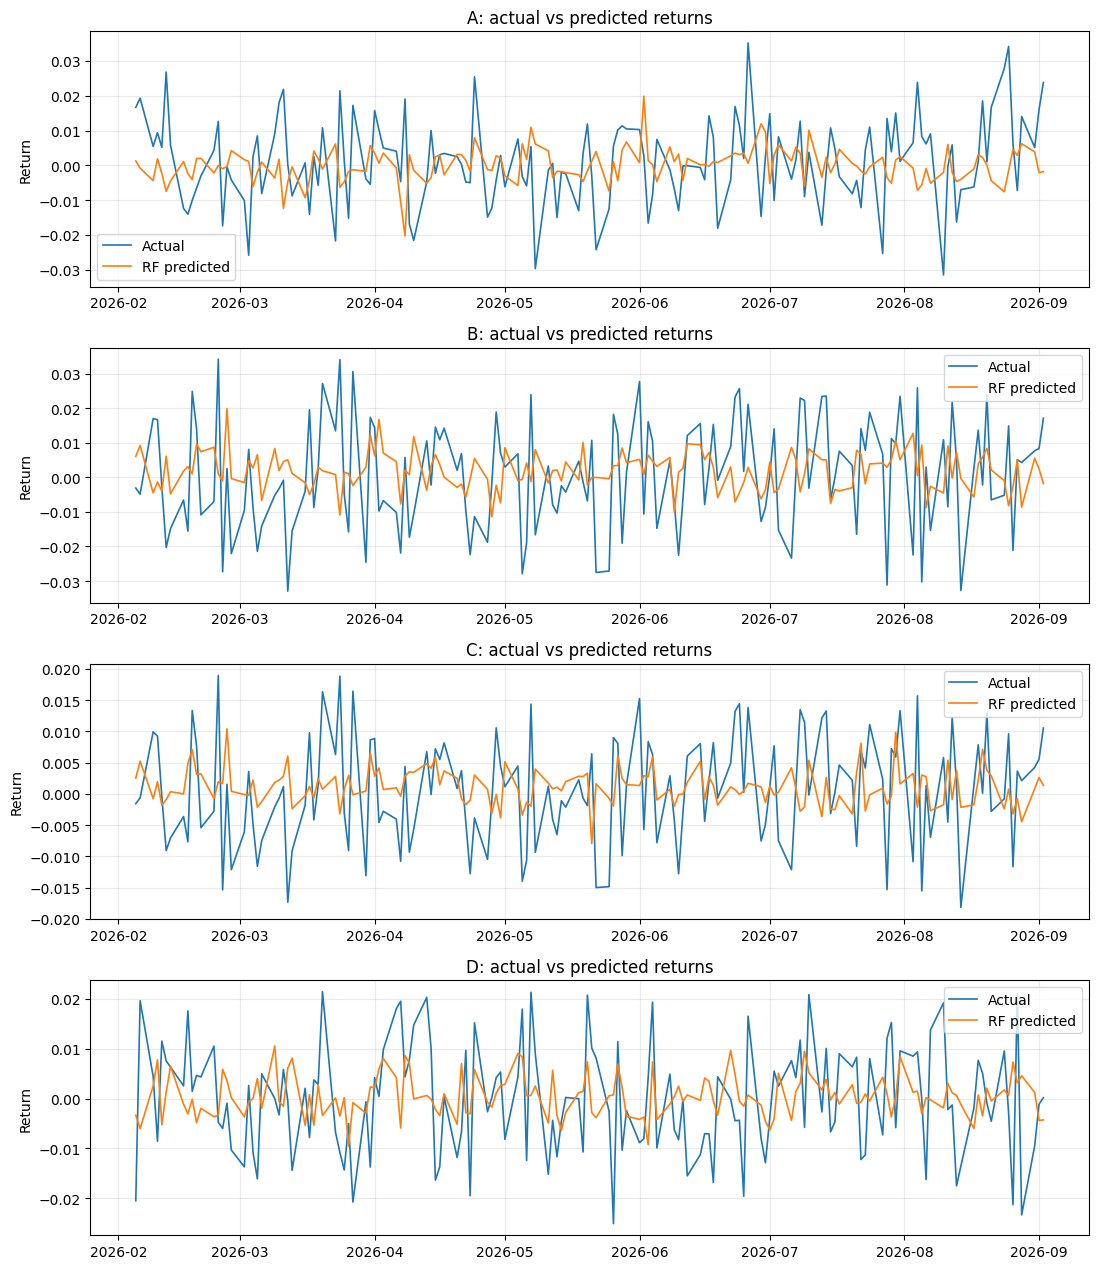

In [7]:
# Cell 7 — Actual vs predicted return plots
fig, axes = plt.subplots(len(assets), 1, figsize=(11, 3.2 * len(assets)), sharex=False)
if len(assets) == 1:
    axes = [axes]

for ax, asset in zip(axes, assets):
    _, _, _, y_test = splits[asset]
    ax.plot(y_test.index, y_test.values, label="Actual", linewidth=1.2)
    ax.plot(predictions[asset].index, predictions[asset].values, label="RF predicted", linewidth=1.2)
    ax.set_title(f"{asset}: actual vs predicted returns")
    ax.set_ylabel("Return")
    ax.legend()
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

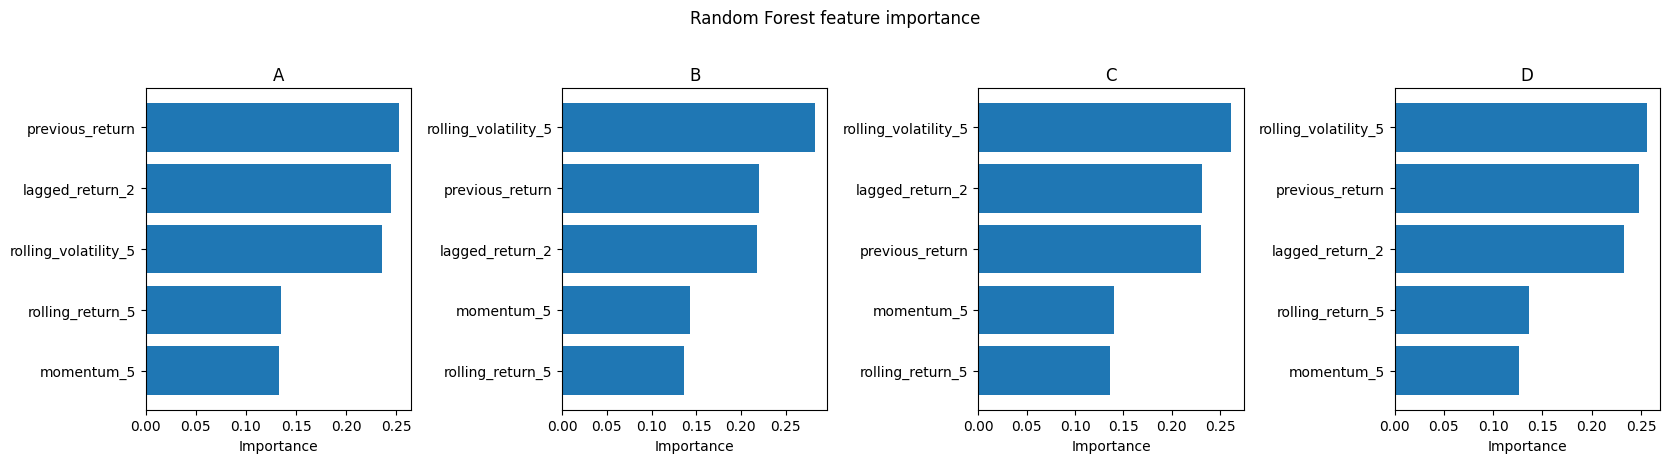

,Asset,Feature,Importance
0,A,previous_return,0.252393
1,A,lagged_return_2,0.244394
3,A,rolling_volatility_5,0.236017
2,A,rolling_return_5,0.134639
4,A,momentum_5,0.132557
8,B,rolling_volatility_5,0.282678
5,B,previous_return,0.220485
6,B,lagged_return_2,0.217996
9,B,momentum_5,0.142792
7,B,rolling_return_5,0.136048


In [8]:
# Cell 8 — Feature importance for each asset
fig, axes = plt.subplots(1, len(assets), figsize=(4.2 * len(assets), 4.5), sharey=False)
if len(assets) == 1:
    axes = [axes]

for ax, asset in zip(axes, assets):
    imp = (feature_importance_df[feature_importance_df["Asset"] == asset]
           .sort_values("Importance", ascending=True))
    ax.barh(imp["Feature"], imp["Importance"])
    ax.set_title(asset)
    ax.set_xlabel("Importance")

plt.suptitle("Random Forest feature importance", y=1.02)
plt.tight_layout()
plt.show()

display(feature_importance_df.sort_values(["Asset", "Importance"], ascending=[True, False]))

In [9]:
# Cell 9 — Construct ML-estimated expected-return vector mu_ml
# Use the mean OUT-OF-SAMPLE Random Forest prediction for each asset, then annualize.
# Random Forest estimates returns; it does NOT optimize the portfolio.
mu_ml_daily = np.array([predictions[a].mean() for a in assets])
mu_ml = mu_ml_daily * TRADING_PERIODS
mu_ml_series = pd.Series(mu_ml, index=assets, name="ML expected return (annualized)")

# Also show the most recent test-set prediction for interpretability.
latest_pred_daily = pd.Series({a: predictions[a].iloc[-1] for a in assets}, name="Latest RF predicted return")

print("mu_ml is the annualized mean of the out-of-sample RF predictions.")
display(mu_ml_series.to_frame())
display(latest_pred_daily.to_frame())

mu_ml is the annualized mean of the out-of-sample RF predictions.


,ML expected return (annualized)
A,-0.008144
B,0.455744
C,0.288562
D,0.119855


,Latest RF predicted return
A,-0.001791
B,-0.001805
C,0.001383
D,-0.004284


In [10]:
# Cell 10 — Historical covariance matrix Sigma
# Risk is estimated from historical returns, NOT from Random Forest predictions.
Sigma = returns[assets].cov().values * TRADING_PERIODS
Sigma_df = pd.DataFrame(Sigma, index=assets, columns=assets)

print("Annualized historical covariance matrix Sigma:")
display(Sigma_df)
print("Symmetric?", np.allclose(Sigma, Sigma.T))
print("Minimum eigenvalue:", np.linalg.eigvalsh(Sigma).min())

Annualized historical covariance matrix Sigma:


,A,B,C,D
A,0.040798,0.008639,0.006428,0.001273
B,0.008639,0.068225,0.037067,0.002813
C,0.006428,0.037067,0.020288,0.003079
D,0.001273,0.002813,0.003079,0.031733


Symmetric? True
Minimum eigenvalue: 1.027297621022571e-06


In [11]:
# Cell 11 — Markowitz objective and common portfolio metrics
RISK_FREE_RATE = 0.0

def portfolio_metrics(weights, mu_vector=mu_ml, covariance=Sigma):
    weights = np.asarray(weights, dtype=float)
    expected_return = float(weights @ mu_vector)
    variance = float(weights @ covariance @ weights)
    volatility = float(np.sqrt(max(variance, 0.0)))
    sharpe = (expected_return - RISK_FREE_RATE) / volatility if volatility > 0 else np.nan
    objective = -expected_return + gamma * variance  # preserved original Markowitz form
    return expected_return, variance, volatility, sharpe, objective

def markowitz_objective(weights):
    return portfolio_metrics(weights)[-1]

def constraints_satisfied(weights, tol=1e-8):
    w = np.asarray(weights, dtype=float)
    return bool(abs(w.sum() - 1.0) <= tol and np.all(w >= -tol) and np.all(w <= 1.0 + tol))

print("Objective: minimize -w^T mu_ml + gamma * w^T Sigma w")
print("gamma =", gamma)
print("Constraints: sum(weights)=1 and 0<=weight_i<=1")

Objective: minimize -w^T mu_ml + gamma * w^T Sigma w
gamma = 1.0
Constraints: sum(weights)=1 and 0<=weight_i<=1


In [12]:
# Cell 12 — SLSQP optimization
n_assets = len(assets)
initial_weights = np.full(n_assets, 1.0 / n_assets)
bounds = [(0.0, 1.0)] * n_assets
constraints = ({"type": "eq", "fun": lambda w: np.sum(w) - 1.0},)

t0 = time.perf_counter()
slsqp_result = minimize(
    markowitz_objective,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"maxiter": 2000, "ftol": 1e-12, "disp": False}
)
slsqp_time = time.perf_counter() - t0

slsqp_weights = slsqp_result.x
slsqp_stats = portfolio_metrics(slsqp_weights)

print("SLSQP success:", slsqp_result.success)
print("Message:", slsqp_result.message)
print("Optimal weights:")
display(pd.Series(slsqp_weights, index=assets, name="SLSQP weight").to_frame())
print("Expected return:", slsqp_stats[0])
print("Variance:", slsqp_stats[1])
print("Volatility:", slsqp_stats[2])
print("Sharpe ratio:", slsqp_stats[3])
print("Objective value:", slsqp_stats[4])
print("Execution time (s):", slsqp_time)
print("Constraint satisfaction:", constraints_satisfied(slsqp_weights))
print("Weight sum:", slsqp_weights.sum())

SLSQP success: True
Message: Optimization terminated successfully
Optimal weights:


,SLSQP weight
A,1.303433e-16
B,1.000000e+00
C,1.110223e-16
D,1.040834e-16


Expected return: 0.45574442859236286
Variance: 0.06822462811239592
Volatility: 0.26119844584605767
Sharpe ratio: 1.744820598438647
Objective value: -0.3875198004799669
Execution time (s): 0.030896140000038486
Constraint satisfaction: True
Weight sum: 1.0


GA weights:


,GA weight
A,0.0
B,1.0
C,0.0
D,0.0


Expected return: 0.4557444285923629
Variance: 0.06822462811239595
Volatility: 0.2611984458460577
Sharpe ratio: 1.744820598438647
Objective value: -0.387519800479967
Execution time (s): 5.613118848999989
Constraint satisfaction: True
Weight sum: 1.0


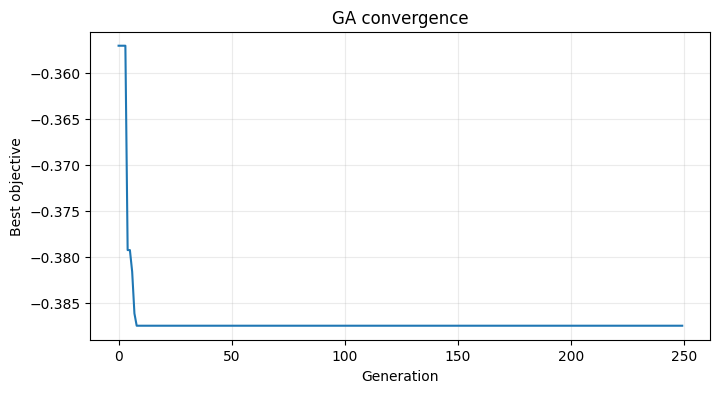

In [13]:
# Cell 13 — Genetic Algorithm using the SAME Markowitz objective
GA_POPULATION = 120
GA_GENERATIONS = 250
GA_ELITE = 12
GA_MUTATION_RATE = 0.15
GA_MUTATION_SCALE = 0.05
GA_TOURNAMENT = 3
GA_SEED = 42

def normalize_weights(w):
    w = np.clip(np.asarray(w, dtype=float), 0.0, None)
    s = w.sum()
    return np.full_like(w, 1.0 / len(w)) if s <= 0 else w / s

def run_ga():
    rng = np.random.default_rng(GA_SEED)
    population = rng.dirichlet(np.ones(n_assets), size=GA_POPULATION)

    def tournament_select(pop, fitness):
        idx = rng.integers(0, len(pop), size=GA_TOURNAMENT)
        return pop[idx[np.argmin(fitness[idx])]].copy()

    best_history = []
    for _ in range(GA_GENERATIONS):
        fitness = np.array([markowitz_objective(ind) for ind in population])
        elite_idx = np.argsort(fitness)[:GA_ELITE]
        new_population = [population[i].copy() for i in elite_idx]
        best_history.append(float(fitness[elite_idx[0]]))

        while len(new_population) < GA_POPULATION:
            p1 = tournament_select(population, fitness)
            p2 = tournament_select(population, fitness)

            alpha = rng.random()
            child = alpha * p1 + (1.0 - alpha) * p2

            if rng.random() < GA_MUTATION_RATE:
                child = child + rng.normal(0.0, GA_MUTATION_SCALE, size=n_assets)

            child = normalize_weights(child)
            new_population.append(child)

        population = np.asarray(new_population[:GA_POPULATION])

    fitness = np.array([markowitz_objective(ind) for ind in population])
    best = population[np.argmin(fitness)]
    return normalize_weights(best), best_history

t0 = time.perf_counter()
ga_weights, ga_history = run_ga()
ga_time = time.perf_counter() - t0
ga_stats = portfolio_metrics(ga_weights)

print("GA weights:")
display(pd.Series(ga_weights, index=assets, name="GA weight").to_frame())
print("Expected return:", ga_stats[0])
print("Variance:", ga_stats[1])
print("Volatility:", ga_stats[2])
print("Sharpe ratio:", ga_stats[3])
print("Objective value:", ga_stats[4])
print("Execution time (s):", ga_time)
print("Constraint satisfaction:", constraints_satisfied(ga_weights))
print("Weight sum:", ga_weights.sum())

plt.figure(figsize=(8, 4))
plt.plot(ga_history)
plt.xlabel("Generation")
plt.ylabel("Best objective")
plt.title("GA convergence")
plt.grid(alpha=0.25)
plt.show()

,Method,Portfolio weights,Expected return,Variance,Volatility,Sharpe ratio,Objective value,Execution time (s),Constraint satisfaction
0,SLSQP,"A=0.0000, B=1.0000, C=0.0000, D=0.0000",0.455744,0.068225,0.261198,1.744821,-0.38752,0.030896,True
1,Genetic Algorithm,"A=0.0000, B=1.0000, C=0.0000, D=0.0000",0.455744,0.068225,0.261198,1.744821,-0.38752,5.613119,True


,SLSQP,Genetic Algorithm
A,1.303433e-16,0.0
B,1.000000e+00,1.0
C,1.110223e-16,0.0
D,1.040834e-16,0.0


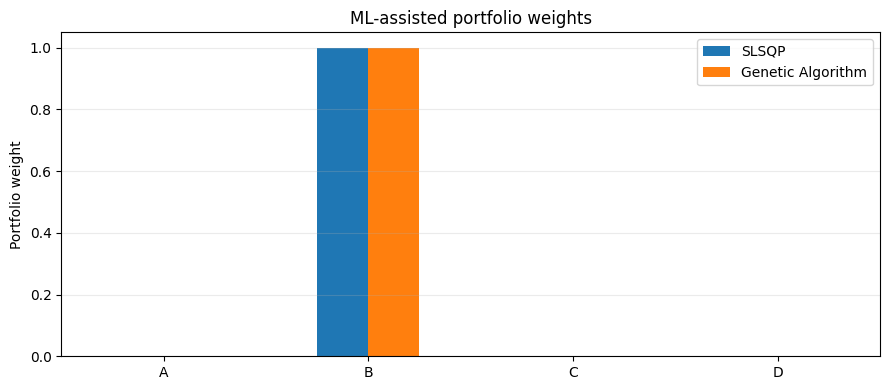

In [14]:
# Cell 14 — Final direct comparison: SLSQP vs GA
def format_weights(w):
    return ", ".join(f"{a}={x:.4f}" for a, x in zip(assets, w))

comparison_df = pd.DataFrame([
    {
        "Method": "SLSQP",
        "Portfolio weights": format_weights(slsqp_weights),
        "Expected return": slsqp_stats[0],
        "Variance": slsqp_stats[1],
        "Volatility": slsqp_stats[2],
        "Sharpe ratio": slsqp_stats[3],
        "Objective value": slsqp_stats[4],
        "Execution time (s)": slsqp_time,
        "Constraint satisfaction": constraints_satisfied(slsqp_weights)
    },
    {
        "Method": "Genetic Algorithm",
        "Portfolio weights": format_weights(ga_weights),
        "Expected return": ga_stats[0],
        "Variance": ga_stats[1],
        "Volatility": ga_stats[2],
        "Sharpe ratio": ga_stats[3],
        "Objective value": ga_stats[4],
        "Execution time (s)": ga_time,
        "Constraint satisfaction": constraints_satisfied(ga_weights)
    }
])

display(comparison_df)

weights_comparison = pd.DataFrame({
    "SLSQP": slsqp_weights,
    "Genetic Algorithm": ga_weights
}, index=assets)
display(weights_comparison)

weights_comparison.plot(kind="bar", figsize=(9, 4))
plt.ylabel("Portfolio weight")
plt.title("ML-assisted portfolio weights")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## What changed from the original notebook?

1. **Preserved:** asset names `A-D`, `gamma = 1.0`, and the original Markowitz form \(-\mu^T w + \gamma w^T\Sigma w\).
2. **Added:** a leakage-safe time-series feature pipeline and one `RandomForestRegressor` per asset.
3. **Replaced only expected-return estimation:** the optimizer receives `mu_ml` instead of the manually entered classical `mu`.
4. **Risk remains historical:** `Sigma` is computed from historical returns, not RF predictions.
5. **Added solvers requested:** continuous long-only Markowitz optimization with SLSQP and a reproducible GA. The attached baseline had neither implementation.
6. **Original QUBO/QAOA section is retained below** as an appendix because it solves a different *binary asset-selection/budget* formulation. Random Forest is not described as an optimizer.

### Methodological statement
**Random Forest Regression → expected-return estimation.**  
**Markowitz → optimization model.**  
**SLSQP / GA → numerical solvers.**

> For final research/competition results, replace demonstration data with real historical prices. Do not present the demonstration series as market data.

---
# Appendix — Original QUBO / Ising / QAOA notebook cells
The following cells are retained from your uploaded baseline for traceability. They are separate from the new ML-assisted continuous-weight SLSQP/GA workflow. They require PennyLane.

In [16]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 78.3 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully uninstalled autograd-1.9.1


In [17]:
import pennylane as qp
from pennylane import numpy as np
from matplotlib import pyplot as plt
import sympy as sp

In [18]:
stocks = ["A", "B", "C", "D"]

# Binary stock variables
xA, xB, xC, xD = sp.symbols("xA xB xC xD")

# All binary variables
variables = [xA, xB, xC, xD]

# Stock decision vector
x = sp.Matrix([xA, xB, xC, xD])


#EXPECTED RETURNS
mu = sp.Matrix([0.08,   # Stock A
                0.12,   # Stock B
                0.15,   # Stock C
                0.07])    # Stock D


# COVARIANCE MATRIX

Sigma = sp.Matrix([[0.04,  0.01,  0.005, 0.002],
                   [0.01,  0.07,  0.015, 0.003],
                   [0.01,  0.07,  0.015, 0.003],
                   [0.002, 0.003, 0.004, 0.03]])


#PORTFOLIO PARAMETERS
gamma = 1.0
lmbd = 100


# 5. BUDGET * 10,000

investment = sp.Matrix([1, 2, 3, 1])
budget = 5


#MARKOWITZ OBJECTIVE
expected_return = (mu.T * x)[0]
risk = (x.T * Sigma * x)[0]

markowitz = (-expected_return + gamma * risk)

print("MARKOWITZ OBJECTIVE")
print(sp.expand(markowitz))


budget_expression = ((investment.T * x)[0] - budget)

print("MARKOWITZ BUDGET")
print(budget_expression)


# QUBO
qubo = (markowitz + lmbd * budget_expression**2)

qubo = sp.expand(qubo)

print("QUBO BEFORE BINARY REDUCTION")
print(qubo)


#BINARY REDUCTION
qubo_binary = qubo

for var in variables:

    qubo_binary = qubo_binary.subs(var**2, var)

qubo_binary = sp.expand(qubo_binary)

print("QUBO AFTER x^2 = x")
print(qubo_binary)

MARKOWITZ OBJECTIVE
0.04*xA**2 + 0.02*xA*xB + 0.015*xA*xC + 0.004*xA*xD - 0.08*xA + 0.07*xB**2 + 0.085*xB*xC + 0.006*xB*xD - 0.12*xB + 0.015*xC**2 + 0.007*xC*xD - 0.15*xC + 0.03*xD**2 - 0.07*xD
MARKOWITZ BUDGET
xA + 2*xB + 3*xC + xD - 5
QUBO BEFORE BINARY REDUCTION
100.04*xA**2 + 400.02*xA*xB + 600.015*xA*xC + 200.004*xA*xD - 1000.08*xA + 400.07*xB**2 + 1200.085*xB*xC + 400.006*xB*xD - 2000.12*xB + 900.015*xC**2 + 600.007*xC*xD - 3000.15*xC + 100.03*xD**2 - 1000.07*xD + 2500
QUBO AFTER x^2 = x
400.02*xA*xB + 600.015*xA*xC + 200.004*xA*xD - 900.04*xA + 1200.085*xB*xC + 400.006*xB*xD - 1600.05*xB + 600.007*xC*xD - 2100.135*xC - 900.04*xD + 2500


In [19]:
poly = sp.Poly(qubo_binary, *variables)

constant = 0
linear_terms = {}
quadratic_terms = {}

for powers, coefficient in poly.terms():

    degree = sum(powers)

    # -------------------------------
    # Constant
    # -------------------------------

    if degree == 0:

        constant += coefficient

    # -------------------------------
    # Linear
    # -------------------------------

    elif degree == 1:

        for i, power in enumerate(powers):

            if power == 1:

                linear_terms[i] = coefficient

    # -------------------------------
    # Quadratic
    # -------------------------------

    elif degree == 2:

        indices = [
            i
            for i, power in enumerate(powers)
            if power == 1
        ]

        if len(indices) == 2:

            quadratic_terms[
                tuple(indices)
            ] = coefficient


print("\n================================================")
print("QUBO CONSTANT")
print("================================================\n")

print(constant)


print("\n================================================")
print("QUBO LINEAR TERMS")
print("================================================\n")

for i, coefficient in linear_terms.items():

    print(
        f"{coefficient} * {variables[i]}"
    )


print("\n================================================")
print("QUBO QUADRATIC TERMS")
print("================================================\n")

for (i, j), coefficient in quadratic_terms.items():

    print(
        f"{coefficient} * "
        f"{variables[i]} * {variables[j]}"
    )


# ============================================================
# 11. QUBO -> ISING
#
# Mapping:
#
#       x_i = (1 - Z_i)/2
#
# ============================================================

Z = sp.symbols("Z0:4")

binary_to_ising = {xA: (1 - Z[0]) / 2,
                   xB: (1 - Z[1]) / 2,
                   xC: (1 - Z[2]) / 2,
                   xD: (1 - Z[3]) / 2}


ising_expression = qubo_binary.subs(binary_to_ising)

ising_expression = sp.expand(ising_expression)

print("\n================================================")
print("ISING HAMILTONIAN")
print("================================================\n")

print(ising_expression)


# ============================================================
# 12. EXTRACT ISING TERMS
#
# H =
#
#       C
#       + sum_i h_i Z_i
#       + sum_ij J_ij Z_i Z_j
#
# ============================================================

ising_poly = sp.Poly(ising_expression, *Z)

ising_constant = 0
ising_linear = {}
ising_quadratic = {}

for powers, coefficient in ising_poly.terms():

    degree = sum(powers)

    # -------------------------------
    # Constant
    # -------------------------------

    if degree == 0:

        ising_constant += coefficient

    # -------------------------------
    # Z_i
    # -------------------------------

    elif degree == 1:

        for i, power in enumerate(powers):

            if power == 1:

                ising_linear[i] = coefficient

    # -------------------------------
    # Z_i Z_j
    # -------------------------------

    elif degree == 2:

        indices = [
            i
            for i, power in enumerate(powers)
            if power == 1
        ]

        if len(indices) == 2:

            ising_quadratic[
                tuple(indices)
            ] = coefficient


print("\n================================================")
print("ISING CONSTANT")
print("================================================\n")

print(ising_constant)


print("\n================================================")
print("ISING LINEAR TERMS")
print("================================================\n")

for i, coefficient in ising_linear.items():

    print(
        f"{coefficient} * Z{i}"
    )


print("\n================================================")
print("ISING QUADRATIC TERMS")
print("================================================\n")

for (i, j), coefficient in ising_quadratic.items():

    print(
        f"{coefficient} * Z{i} Z{j}"
    )


# ============================================================
# 13. CREATE PENNYLANE HAMILTONIAN
# ============================================================

coefficients = []
observables = []

# -------------------------------
# Constant term
# -------------------------------

coefficients.append(float(ising_constant))
observables.append(qp.Identity(0))


# -------------------------------
# Linear terms
# -------------------------------

for i, coefficient in ising_linear.items():

    coefficients.append(float(coefficient))
    observables.append(qp.PauliZ(i))


# -------------------------------
# Quadratic terms
# -------------------------------

for (i, j), coefficient in ising_quadratic.items():

    coefficients.append(float(coefficient))

    observables.append(
        qp.PauliZ(i) @ qp.PauliZ(j)
    )


# -------------------------------
# PennyLane Hamiltonian
# -------------------------------

H = qp.Hamiltonian(
    coefficients,
    observables
)

print(H)


print("\n================================================")
print("PENNYLANE ISING HAMILTONIAN")
print("================================================\n")

print(H)


QUBO CONSTANT

2500.00000000000

QUBO LINEAR TERMS

-900.040000000000 * xA
-1600.05000000000 * xB
-2100.13500000000 * xC
-900.040000000000 * xD

QUBO QUADRATIC TERMS

400.020000000000 * xA * xB
600.015000000000 * xA * xC
200.004000000000 * xA * xD
1200.08500000000 * xB * xC
400.006000000000 * xB * xD
600.007000000000 * xC * xD

ISING HAMILTONIAN

100.005*Z0*Z1 + 150.00375*Z0*Z2 + 50.001*Z0*Z3 + 150.01025*Z0 + 300.02125*Z1*Z2 + 100.0015*Z1*Z3 + 299.99725*Z1 + 150.00175*Z2*Z3 + 450.04075*Z2 + 150.01575*Z3 + 599.90175

ISING CONSTANT

599.901750000000

ISING LINEAR TERMS

150.010250000000 * Z0
299.997250000000 * Z1
450.040750000000 * Z2
150.015750000000 * Z3

ISING QUADRATIC TERMS

100.005000000000 * Z0 Z1
150.003750000000 * Z0 Z2
50.0010000000000 * Z0 Z3
300.021250000000 * Z1 Z2
100.001500000000 * Z1 Z3
150.001750000000 * Z2 Z3
599.9017499999998 * I(0) + 150.01025 * Z(0) + 299.99725 * Z(1) + 450.0407500000001 * Z(2) + 150.01575000000003 * Z(3) + 100.005 * (Z(0) @ Z(1)) + 150.00375 * (Z(

In [20]:
H_mix = qp.Hamiltonian([1, 1, 1, 1],
                       [qp.PauliX(0),
                        qp.PauliX(1),
                        qp.PauliX(2),
                        qp.PauliX(3)])
H, H_mix

((
     599.9017499999998 * I(0)
   + 150.01025 * Z(0)
   + 299.99725 * Z(1)
   + 450.0407500000001 * Z(2)
   + 150.01575000000003 * Z(3)
   + 100.005 * (Z(0) @ Z(1))
   + 150.00375 * (Z(0) @ Z(2))
   + 50.001000000000005 * (Z(0) @ Z(3))
   + 300.02125 * (Z(1) @ Z(2))
   + 100.0015 * (Z(1) @ Z(3))
   + 150.00175000000002 * (Z(2) @ Z(3))
 ),
 1 * X(0) + 1 * X(1) + 1 * X(2) + 1 * X(3))

In [21]:
dev = qp.device("default.qubit")

def qaoa_layer(gamma, alpha):
    qp.qaoa.cost_layer(gamma, H/100)
    qp.qaoa.mixer_layer(alpha, H_mix)


wires = range(4)
depth = 5

def circuit(params, **kwargs):
    for w in wires:
        qp.Hadamard(wires=w)
    for i in range(depth):
        qaoa_layer(
            params[0, i],
            params[1, i]
        )

In [22]:
@qp.qnode(dev)

def cost_function(params):
    circuit(params)
    return qp.expval(H)

optimizer = qp.AdamOptimizer(stepsize=0.001)
steps = 200

In [23]:
params = qp.numpy.array([[0.1, 0.1, 0.1, 0.1, 0.1],   # gammas
                         [0.2, 0.2, 0.2, 0.2, 0.2]]    # betas
, requires_grad=True)


for i in range(steps):

    params = optimizer.step(cost_function, params)

    if i % 10 == 0:
        print(
            f"Step {i}: "
            f"Cost = {cost_function(params):.6f}"
        )

print("Final cost:", cost_function(params))
print("Final params:")
print(params)

Step 0: Cost = 1141.861072
Step 10: Cost = 1015.422968
Step 20: Cost = 894.875477
Step 30: Cost = 787.917372
Step 40: Cost = 702.610390
Step 50: Cost = 634.868346
Step 60: Cost = 570.037146
Step 70: Cost = 515.180116
Step 80: Cost = 471.120956
Step 90: Cost = 439.380397
Step 100: Cost = 418.973588
Step 110: Cost = 407.221003
Step 120: Cost = 400.871152
Step 130: Cost = 397.377209
Step 140: Cost = 395.189530
Step 150: Cost = 393.524901
Step 160: Cost = 392.039951
Step 170: Cost = 390.607913
Step 180: Cost = 389.192910
Step 190: Cost = 387.790492
Final cost: 386.5416267063144
Final params:
[[0.15364264 0.17161511 0.16374655 0.06167296 0.00513656]
 [0.13053707 0.1305322  0.26883339 0.3292836  0.3261203 ]]


In [24]:
@qp.qnode(dev)
def probability_circuit(params):
    circuit(params)
    return qp.probs(wires=wires)


probs = probability_circuit(params)

In [25]:
probs

tensor([0.00935818, 0.03649774, 0.066908  , 0.03194126, 0.0903765 ,
        0.04235256, 0.1361584 , 0.01018036, 0.03649647, 0.09251393,
        0.03194178, 0.25035422, 0.04234889, 0.10718305, 0.0101822 ,
        0.00520646], requires_grad=True)

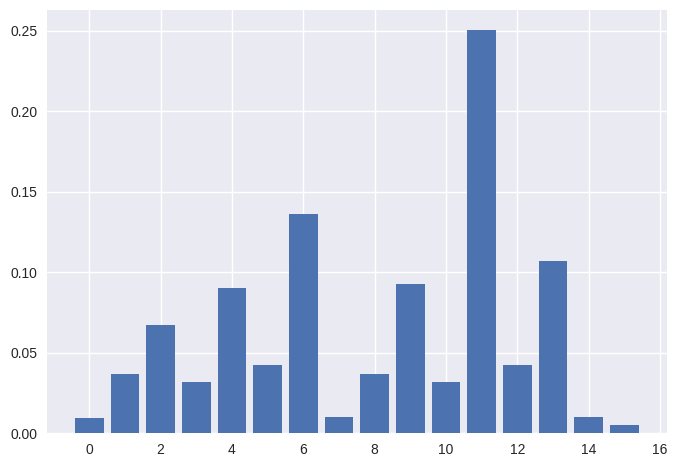

In [26]:
plt.style.use("seaborn-v0_8")
plt.bar(range(2 ** len(wires)), probs)
plt.show()

In [27]:
import itertools

for bits in itertools.product([0, 1], repeat=4):

    energy = 0.0

    for coeff, op in zip(H.coeffs, H.ops):

        value = float(coeff)

        # Get the wires on which this operator acts
        for wire in op.wires:

            if bits[wire] == 0:
                z = 1
            else:
                z = -1

            value *= z

        energy += value

    print(bits, energy)

(0, 0, 0, 0) 2500.0
(0, 0, 0, 1) 1599.96
(0, 0, 1, 0) 399.86499999999955
(0, 0, 1, 1) 99.83199999999962
(0, 1, 0, 0) 899.95
(0, 1, 0, 1) 399.9159999999998
(0, 1, 1, 0) -0.10000000000027853
(0, 1, 1, 1) 99.87299999999973
(1, 0, 0, 0) 400.1565000000004
(1, 0, 0, 1) -299.87949999999967
(1, 0, 1, 0) -1099.9634999999998
(1, 0, 1, 1) -1199.9925000000003
(1, 1, 0, 0) -799.8734999999995
(1, 1, 0, 1) -1099.9034999999997
(1, 1, 1, 0) -1099.9084999999995
(1, 1, 1, 1) -799.9314999999997


In [28]:
import itertools

for bits in itertools.product([0, 1], repeat=4):

    xa, xb, xc, xd = bits

    energy = (
        -expected_return.subs({
            xA: xa,
            xB: xb,
            xC: xc,
            xD: xd
        })
        + gamma * risk.subs({
            xA: xa,
            xB: xb,
            xC: xc,
            xD: xd
        })
        + lmbd * (
            xa + 2*xb + 3*xc + xd - 5
        )**2
    )

    print(bits, float(energy))

(0, 0, 0, 0) 2500.0
(0, 0, 0, 1) 1599.96
(0, 0, 1, 0) 399.865
(0, 0, 1, 1) 99.832
(0, 1, 0, 0) 899.95
(0, 1, 0, 1) 399.916
(0, 1, 1, 0) -0.1
(0, 1, 1, 1) 99.873
(1, 0, 0, 0) 1599.96
(1, 0, 0, 1) 899.924
(1, 0, 1, 0) 99.84
(1, 0, 1, 1) -0.18899999999999997
(1, 1, 0, 0) 399.93
(1, 1, 0, 1) 99.9
(1, 1, 1, 0) 99.895
(1, 1, 1, 1) 399.872
